# Analyse ketamine effect on trace


In [97]:
import os
import sys, pathlib
import numpy as np

sys.path.append(os.path.join(os.path.expanduser('~'), 'Programming', 'In_Vivo','physion', 'src'))

from physion.utils import plot_tools as pt
from physion.analysis.read_NWB import Data, scan_folder_for_NWBfiles
from physion.dataviz.imaging import show_CaImaging_FOV
from physion.dataviz.raw import plot as plot_raw, find_default_plot_settings
#from physion.dataviz.raw import plot_test
from physion.dataviz import tools as dv_tools

import matplotlib.pyplot as plt

base_path = os.path.join(os.path.expanduser('~'), 'Desktop', 'NWBs')

In [98]:
# Function to generate full paths
def generate_file_paths(filenames_list, base_path):
    return [os.path.join(base_path, filename) for filename in filenames_list]

# Function to load data and process
def load_and_process_data(filenames):
    data_list = []
    for filename in filenames:
        print(filename)
        data = Data(filename, verbose=False)
        data.build_dFoF(method_for_F0='sliding_percentile',
                        verbose=False)
        data_list.append(data)
    return data_list

def process_data(data):
    data.build_dFoF(method_for_F0='sliding_percentile',
                    verbose=False)
    setattr(data, 'new', 0)
    
def get_dFoF(the_list):
    dFoF_all = []
    for data in DATA_monitoring_keta:
        dFoF_all.append(data.dFoF)
    return dFoF_all

def check_group(the_list): #prints (number ROIs, number datapoints)
    for i in range(0, len(the_list)):
        print(the_list[i].dFoF.shape)

def average_ROIs(the_list):
    list_mean_ROIs = []
    for i in range(0, len(the_list)):
        mean_ROIs = np.mean(the_list[i].dFoF, axis=0)
        list_mean_ROIs.append(mean_ROIs)
        #print(mean_ROIs)
        #print(mean_ROIs.shape)
    return list_mean_ROIs

def pad_list(n_array):
    max_length = max(len(arr) for arr in n_array)
    padded_arrays = np.array([np.pad(arr, (0, max_length - len(arr)), constant_values=np.nan) for arr in n_array])
    #print(padded_arrays.shape)
    return padded_arrays

In [101]:
fns = generate_file_paths(names_monitoring_keta, base_path)
data = Data(fns[0], verbose=False)

['C:\\Users\\laura.gonzalez\\Desktop\\NWBs\\2024_10_07-16-26-15.nwb', 'C:\\Users\\laura.gonzalez\\Desktop\\NWBs\\2024_10_11-14-13-22.nwb', 'C:\\Users\\laura.gonzalez\\Desktop\\NWBs\\2024_10_11-15-46-32.nwb', 'C:\\Users\\laura.gonzalez\\Desktop\\NWBs\\2024_10_11-17-26-55.nwb']



calculating dF/F with method "percentile" [...]

  ** all ROIs passed the positive F0 criterion ** 

-> dFoF calculus done !  (calculation took 0.0s)


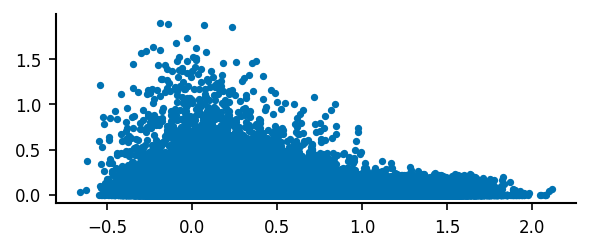

In [108]:
data.build_dFoF()
data.t_dFoF[-1]
data.build_pupil_diameter()
running_FaceCamera_sampled = data.build_running_speed(specific_time_sampling=data.t_rawFluo)
running_dFoF_sampled = data.build_running_speed(specific_time_sampling=data.t_dFoF)
pt.figure(figsize=(2,2))
plt.scatter(data.dFoF[0,:], running_dFoF_sampled)

In [35]:
data.metadata

{'config': 'Yann-A1-2P',
 'date': '2024_10_07',
 'time': '16-26-15',
 'protocol': 'injection-monitoring',
 'VisualStim': True,
 'recording': '',
 'notes': 'Ketamine injection 16:19',
 'FOV': '',
 'subject_ID': 'demo-Mouse',
 'NIdaq-acquisition-frequency': 10000,
 'NIdaq-analog-input-channels': 1,
 'NIdaq-digital-input-channels': 2,
 'Rig': 'ICM-A1-2P-setup',
 'Screen': 'Dell-2020',
 'Z-sign-correction-for-rig': -1,
 'FaceCamera-frame-rate': 30,
 'FaceCamera-1cm-in-pix': 480,
 'RigCamera-frame-rate': 20,
 'RigCamera-1cm-in-pix': 33,
 'Height-of-Microscope-Camera-Image-in-mm': 2.7,
 'rotating-disk': {'radius-position-on-disk-cm': 9.0,
  'roto-encoder-value-per-rotation': -25300.0},
 'root_datafolder': 'DATA',
 'subjects_folder': 'Yann',
 'experimenter': 'Yann Zerlaut',
 'lab': 'Rebola and Bacci labs',
 'institution': 'Institut du Cerveau et de la Moelle, Paris',
 'protocols': array(['injection-monitoring'], dtype='<U20'),
 'Locomotion': True,
 'FaceCamera': True,
 'RigCamera': False,
 'N

In [79]:
data.init_visual_stim()
from scipy import stats

In [75]:
from physion.analysis.process_NWB import EpisodeData
ep = EpisodeData(data,
                 prestim_duration=2,
                 protocol_id=0,
                 quantities=['dFoF'])

  Number of episodes over the whole recording: 304/304 (with protocol condition)
  building episodes with 1 modalities [...]
  -> [ok] episodes ready !


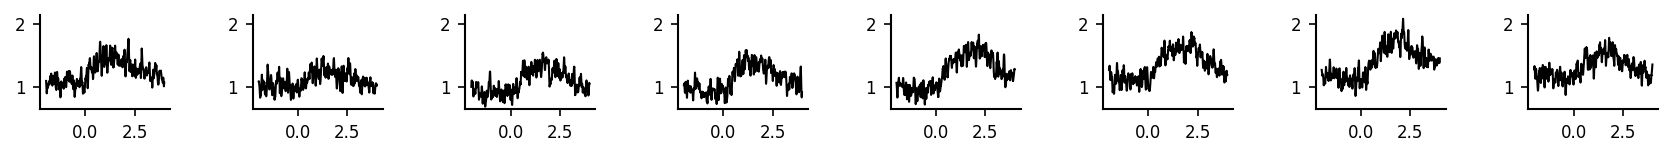

In [82]:
fig, AX = pt.figure(axes=(8,1))
roi=15
for angle, ax in zip(np.unique(ep.angle), AX):
    pt.plot(ep.t, 
            ep.dFoF[ep.angle==angle, roi, :].mean(axis=0), 
            #sy=ep.dFoF[ep.angle==angle, roi, :].std(axis=0), 
            #sy=stats.sem(ep.dFoF[ep.angle==angle, roi, :], axis=0), 
            ax=ax, title='%.1fdeg'%angle)
pt.set_common_ylims(AX)

In [83]:
ep.dFoF[ep.angle==0, roi, :]

array([[0.32687503, 0.3224934 , 0.31811176, ..., 0.22857951, 0.23116874,
        0.23375798],
       [0.53489416, 0.52297827, 0.51106239, ..., 0.13643875, 0.13573205,
        0.13502536],
       [0.97502686, 0.95039527, 0.92576369, ..., 1.4538094 , 1.51933767,
        1.58486593],
       ...,
       [2.20523378, 2.15757672, 2.10991966, ..., 3.8462515 , 3.88625789,
        3.92626427],
       [1.69749852, 1.7189073 , 1.74031608, ..., 0.15071549, 0.16287486,
        0.17503423],
       [3.06224865, 3.08582285, 3.08075231, ..., 1.14224919, 1.20166667,
        1.26108415]])

X-bar label automatically set to:  0.7  Using the format %.1f  --> adjust it and add units through the format !
Y-bar label automatically set to:  0.7  Using the format %.1f  --> adjust it and add units through the format !


(<Figure size 750x450 with 8 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >]], dtype=object))

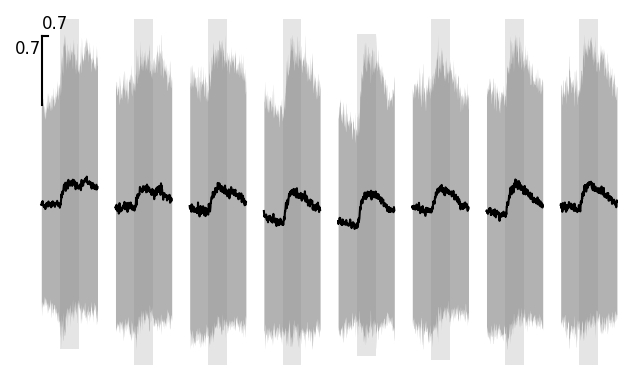

In [87]:
from physion.dataviz.episodes.trial_average import plot as plot_trial_average
plot_trial_average(ep, column_key='angle')

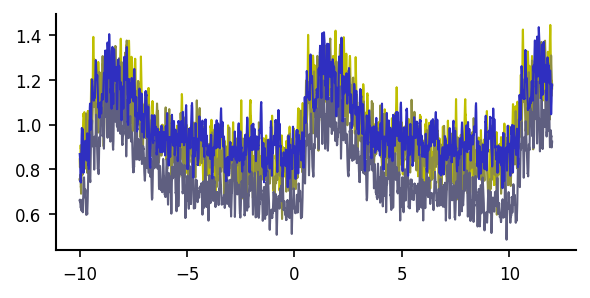

In [66]:
# ep.dFoF.shape (trials, rois, time samples)
roi = 15
fig, ax = pt.figure(figsize=(2, 2.5))
for i in range(4):
    ax.plot(ep.t, ep.dFoF[i*60:(1+i)*60,roi,:].mean(axis=0), color=pt.get_linear_colormap('y', 'b')(i/4))

In [8]:
# Define filenames
names_monitoring_keta = ["2024_10_07-16-26-15.nwb", "2024_10_11-14-13-22.nwb", "2024_10_11-15-46-32.nwb", "2024_10_11-17-26-55.nwb"]
names_8ori_keta       = ["2024_09_12-14-57-34.nwb", "2024_09_12-15-24-47.nwb", "2024_09_12-15-50-12.nwb", "2024_10_07-15-03-40.nwb", 
                         "2024_10_07-17-18-53.nwb", "2024_10_11-14-57-27.nwb", "2024_10_11-16-44-26.nwb", "2024_10_11-18-24-27.nwb"]
names_8ori_saline     = ["2024_08_27-12-21-14.nwb", "2024_08_27-12-46-41.nwb"]

# Generate file paths
filenames_monitoring_keta = generate_file_paths(names_monitoring_keta)
filenames_8ori_keta = generate_file_paths(names_8ori_keta)
filenames_8ori_saline = generate_file_paths(names_8ori_saline)

# Load and process data
DATA_monitoring_keta = load_and_process_data(filenames_monitoring_keta)
DATA_8ori_keta = load_and_process_data(filenames_8ori_keta)
DATA_8ori_saline = load_and_process_data(filenames_8ori_saline)

C:\Users\laura.gonzalez\Desktop\NWBs\2024_10_07-16-26-15.nwb
C:\Users\laura.gonzalez\Desktop\NWBs\2024_10_11-14-13-22.nwb
C:\Users\laura.gonzalez\Desktop\NWBs\2024_10_11-15-46-32.nwb
C:\Users\laura.gonzalez\Desktop\NWBs\2024_10_11-17-26-55.nwb
C:\Users\laura.gonzalez\Desktop\NWBs\2024_09_12-14-57-34.nwb
C:\Users\laura.gonzalez\Desktop\NWBs\2024_09_12-15-24-47.nwb
C:\Users\laura.gonzalez\Desktop\NWBs\2024_09_12-15-50-12.nwb
C:\Users\laura.gonzalez\Desktop\NWBs\2024_10_07-15-03-40.nwb
C:\Users\laura.gonzalez\Desktop\NWBs\2024_10_07-17-18-53.nwb
C:\Users\laura.gonzalez\Desktop\NWBs\2024_10_11-14-57-27.nwb
C:\Users\laura.gonzalez\Desktop\NWBs\2024_10_11-16-44-26.nwb
C:\Users\laura.gonzalez\Desktop\NWBs\2024_10_11-18-24-27.nwb
C:\Users\laura.gonzalez\Desktop\NWBs\2024_08_27-12-21-14.nwb
C:\Users\laura.gonzalez\Desktop\NWBs\2024_08_27-12-46-41.nwb


In [105]:
GROUPS = {'monitoring_keta':{'files':names_monitoring_keta},
          '8ori_keta':{'files':names_8ori_keta},
          '8ori_saline':{'files':names_8ori_saline}}

for group in GROUPS:
    GROUPS[group]['data'] = []
    for f in GROUPS[group]['files']:
        GROUPS[group]['data'].append(Data(os.path.join(base_path, f), verbose=False))
        process_data(GROUPS[group]['data'][-1])
        

In [107]:
print(GROUPS)

{'monitoring_keta': {'files': ['2024_10_07-16-26-15.nwb', '2024_10_11-14-13-22.nwb', '2024_10_11-15-46-32.nwb', '2024_10_11-17-26-55.nwb'], 'data': [<physion.analysis.read_NWB.Data object at 0x000001E92C5E3980>, <physion.analysis.read_NWB.Data object at 0x000001E92C570740>, <physion.analysis.read_NWB.Data object at 0x000001E930105160>, <physion.analysis.read_NWB.Data object at 0x000001E93012AC60>]}, '8ori_keta': {'files': ['2024_09_12-14-57-34.nwb', '2024_09_12-15-24-47.nwb', '2024_09_12-15-50-12.nwb', '2024_10_07-15-03-40.nwb', '2024_10_07-17-18-53.nwb', '2024_10_11-14-57-27.nwb', '2024_10_11-16-44-26.nwb', '2024_10_11-18-24-27.nwb'], 'data': [<physion.analysis.read_NWB.Data object at 0x000001E93012AC30>, <physion.analysis.read_NWB.Data object at 0x000001E93012A030>, <physion.analysis.read_NWB.Data object at 0x000001E91B300EC0>, <physion.analysis.read_NWB.Data object at 0x000001E91B36C9E0>, <physion.analysis.read_NWB.Data object at 0x000001E92FE2FFB0>, <physion.analysis.read_NWB.Data 

AttributeError: 'str' object has no attribute 'dFoF'

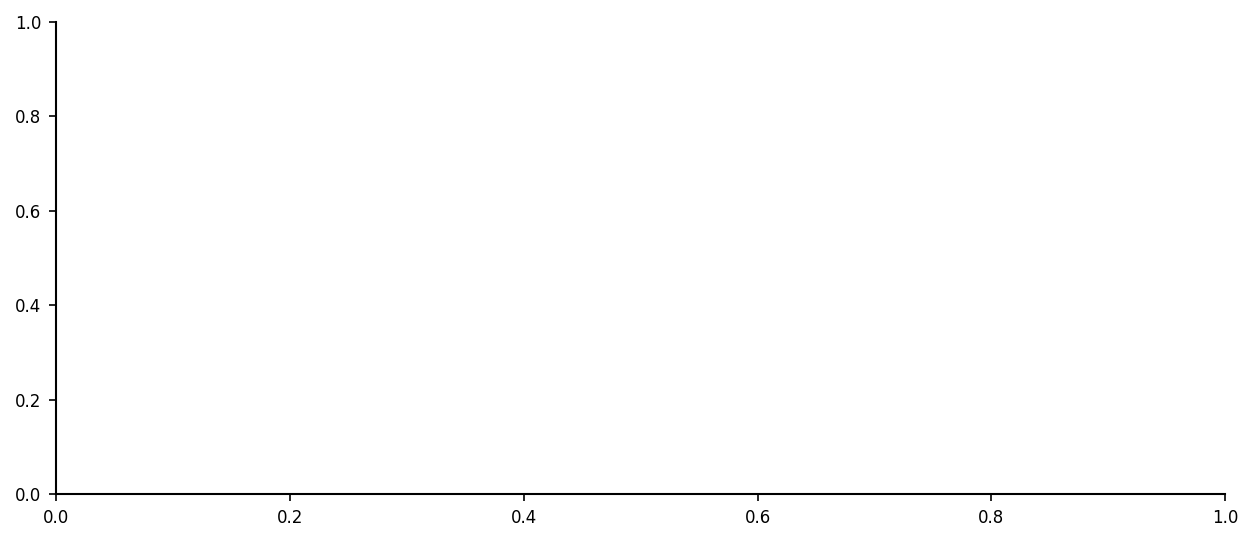

In [106]:
#GROUPS = [DATA_monitoring_keta, DATA_8ori_keta, DATA_8ori_saline]
#GROUPS_names = ['DATA_monitoring_keta', 'DATA_8ori_keta', 'DATA_8ori_saline']

i= 0
fig, AX = pt.figure(axes=(1,1), figsize=(3,5), wspace=0.15)
for group in GROUPS:
    dFoF_all = get_dFoF(group)
    list_mean_ROIs = average_ROIs(group)
    pad_list_mean_ROIs = pad_list(list_mean_ROIs)
    mean_group = np.mean(pad_list_mean_ROIs, axis=0)
    plt.plot(mean_group, label=GROUPS.keys())
    i+=1

pt.set_plot(AX, xlim=(20000, 21000))
plt.legend() 

## Calcium imaging per group (individual animals)

In [11]:
#put the key of what you want to plot
settings = {'CaImaging_mean': {'fig_fraction': 10,
                             'subsampling': 1,
                             'subquantity': 'dF/F', 
                             'color': '#2ca02c'}}

def plot_data(the_list, settings, protocol):
    for data in the_list:
        fig, AX = pt.figure(axes=(1,1), figsize=(3,5), wspace=0.15)
        plot_raw(data, tlim=[0, data.t_dFoF[-1]], settings=settings, ax=AX)
        fig.savefig(os.path.join(os.path.expanduser('~'), 'Desktop', protocol, f'{data.filename}.png'))

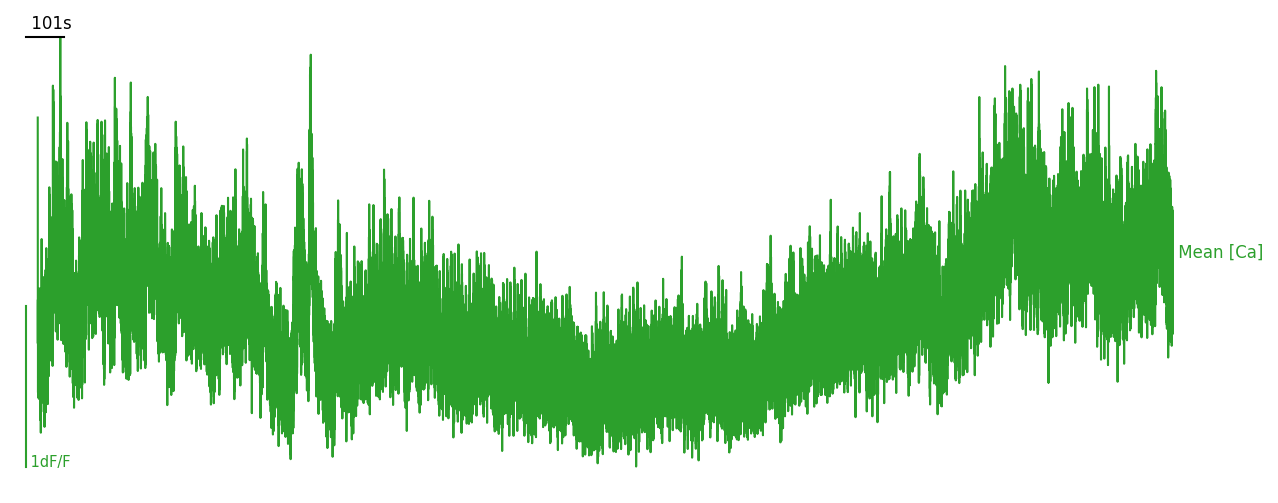

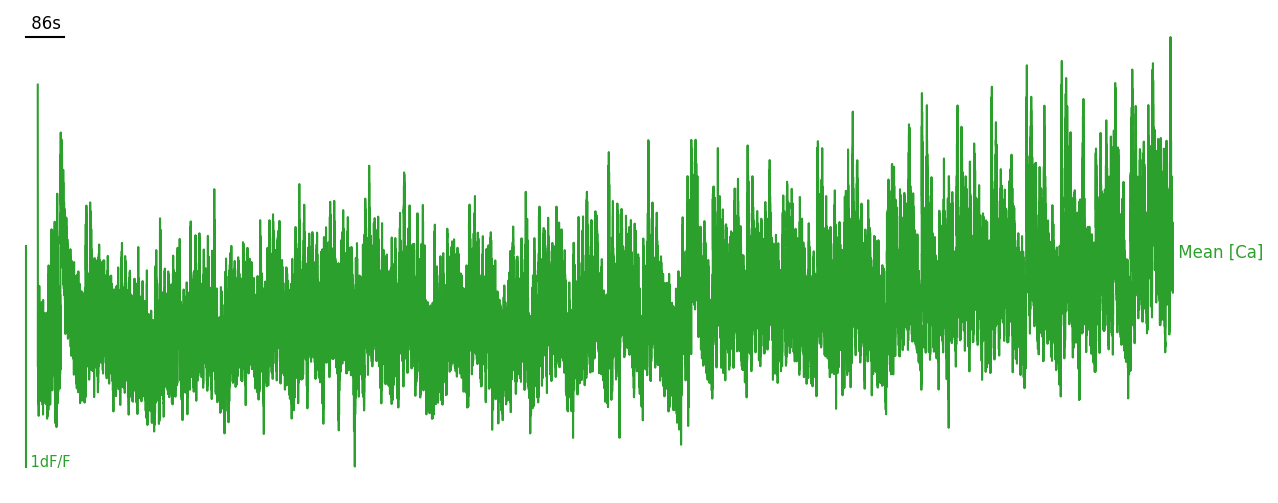

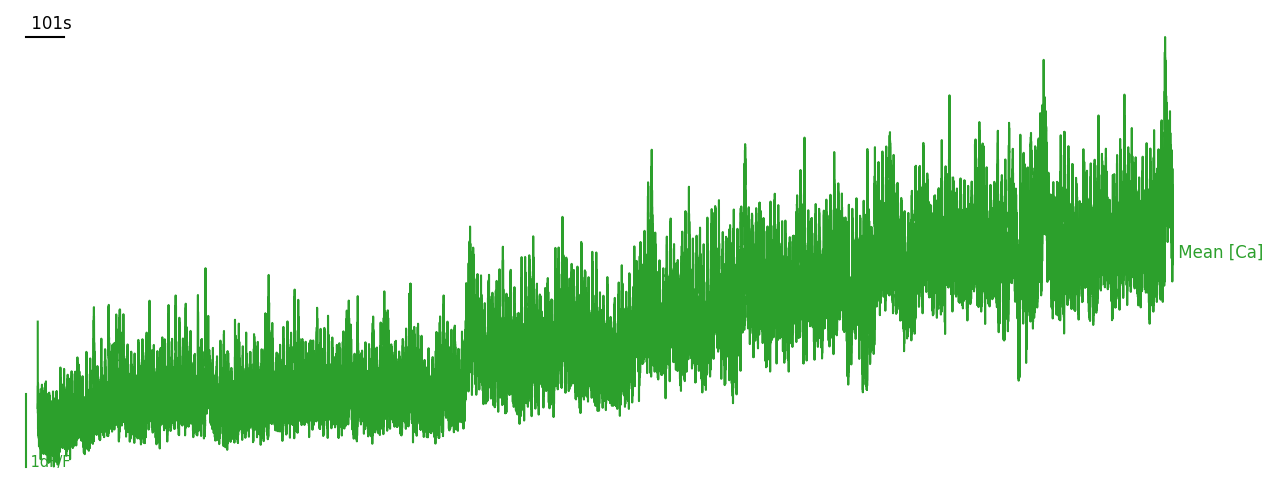

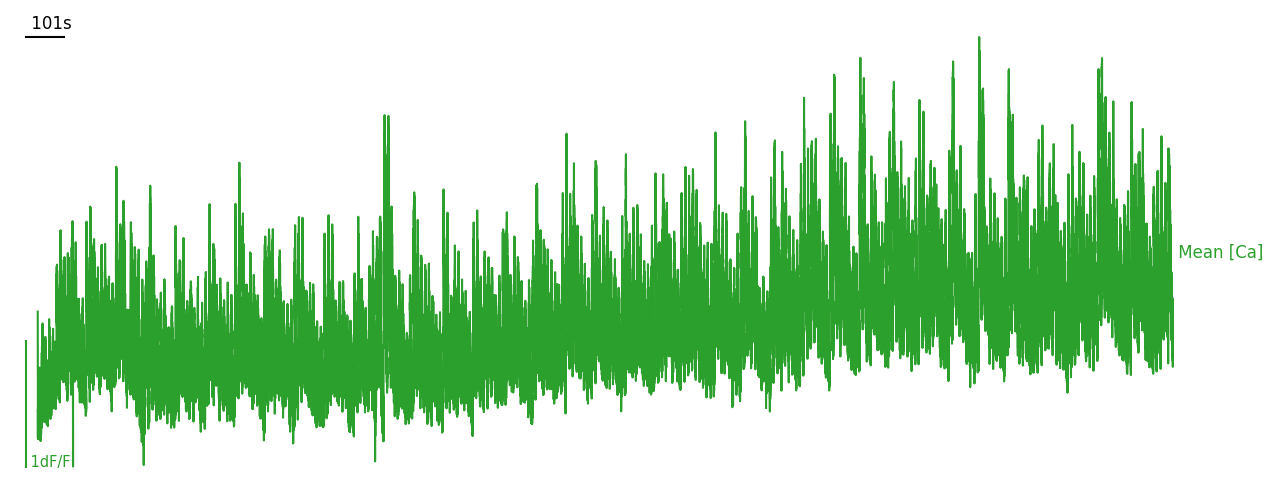

In [12]:
plot_data(DATA_monitoring_keta, settings, 'Injection_monitoring')

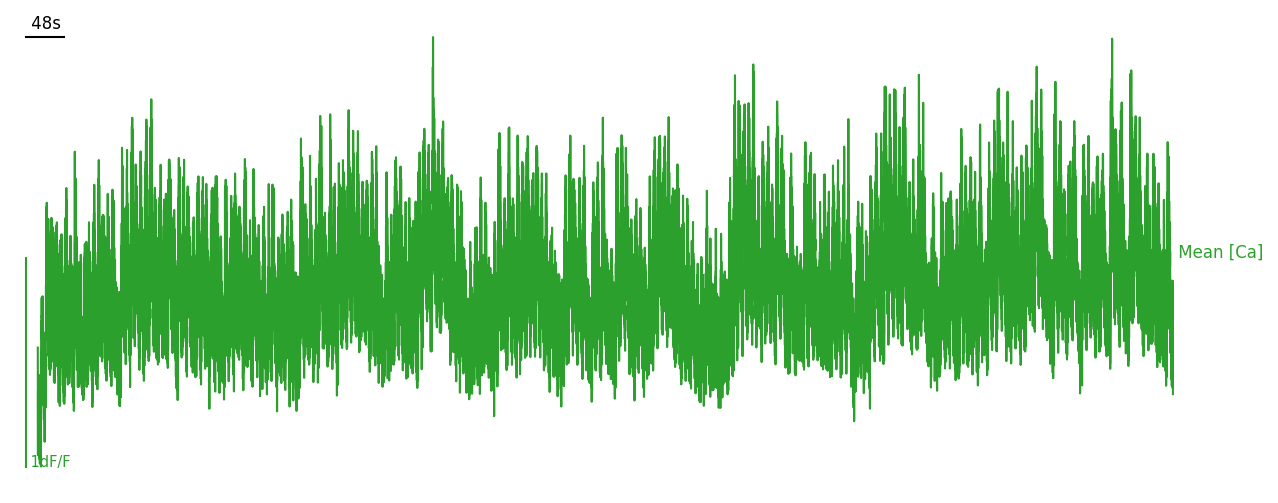

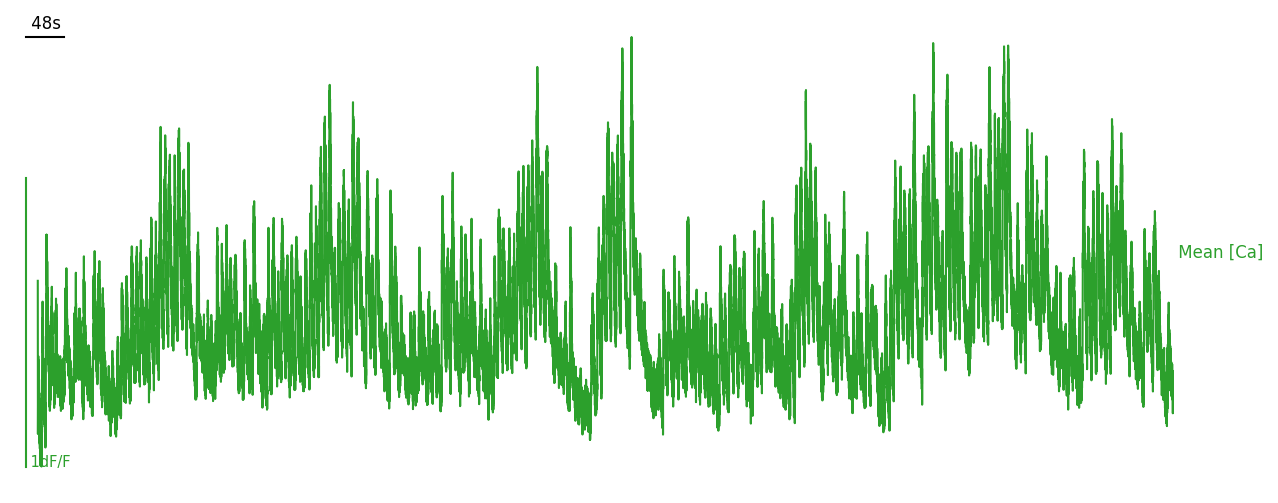

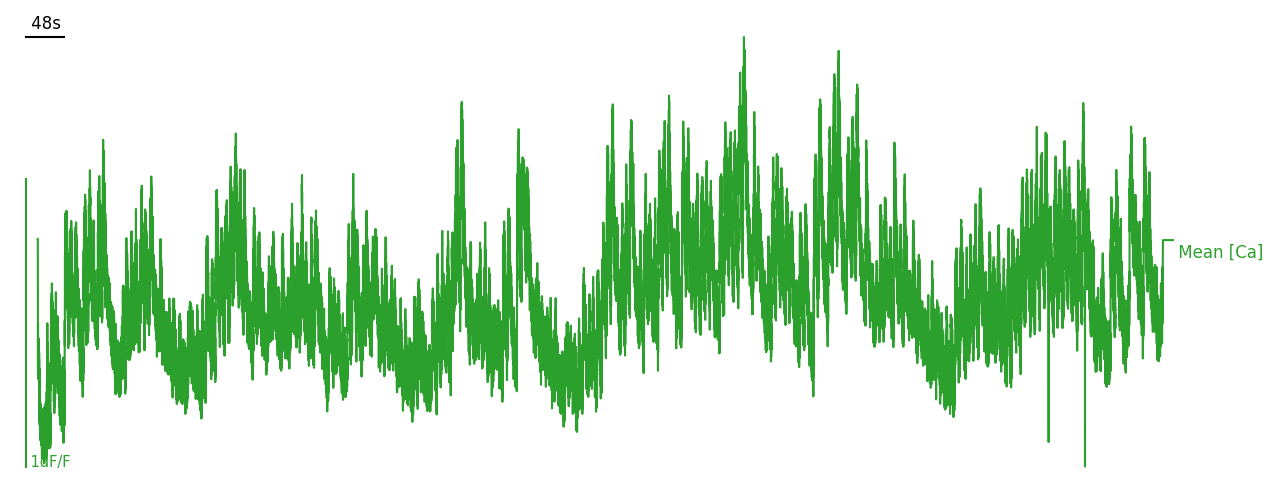

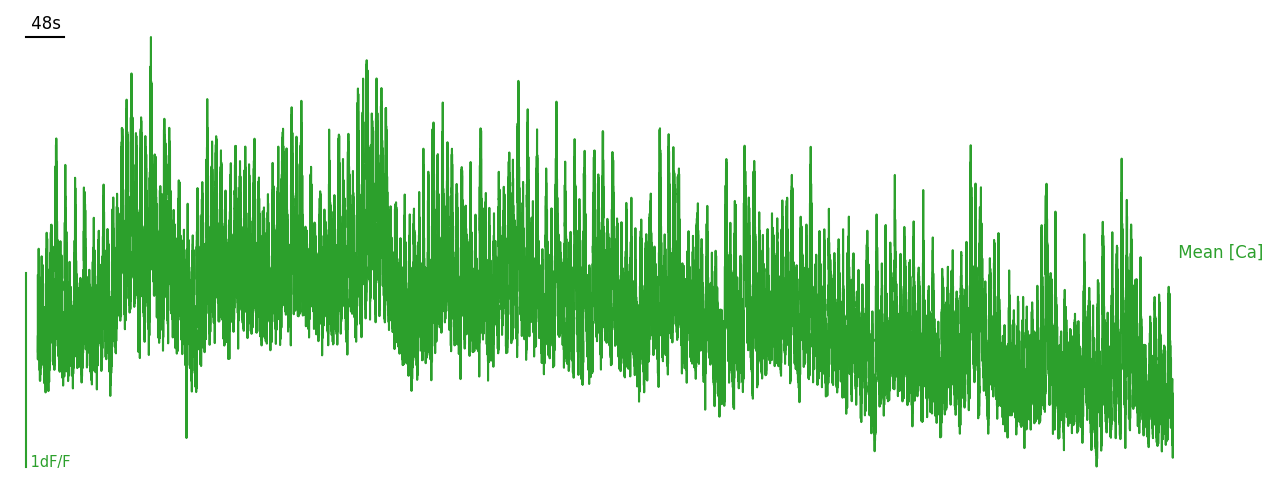

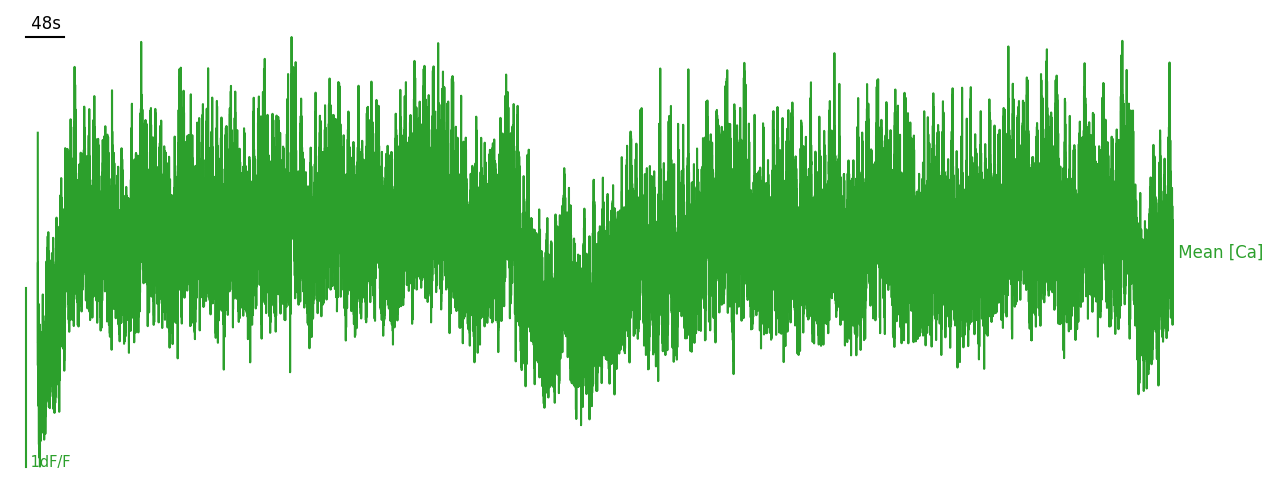

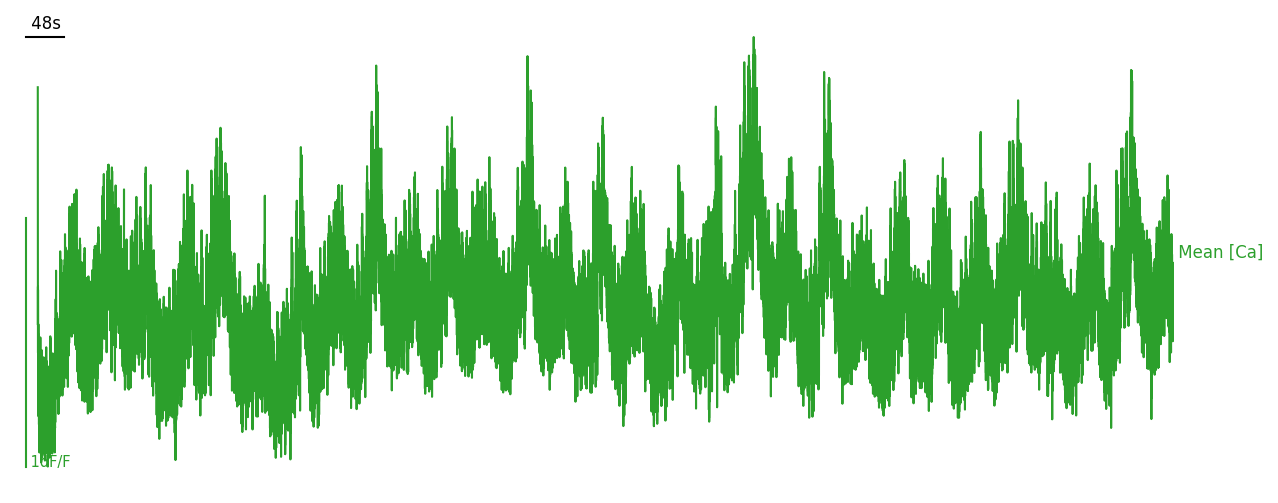

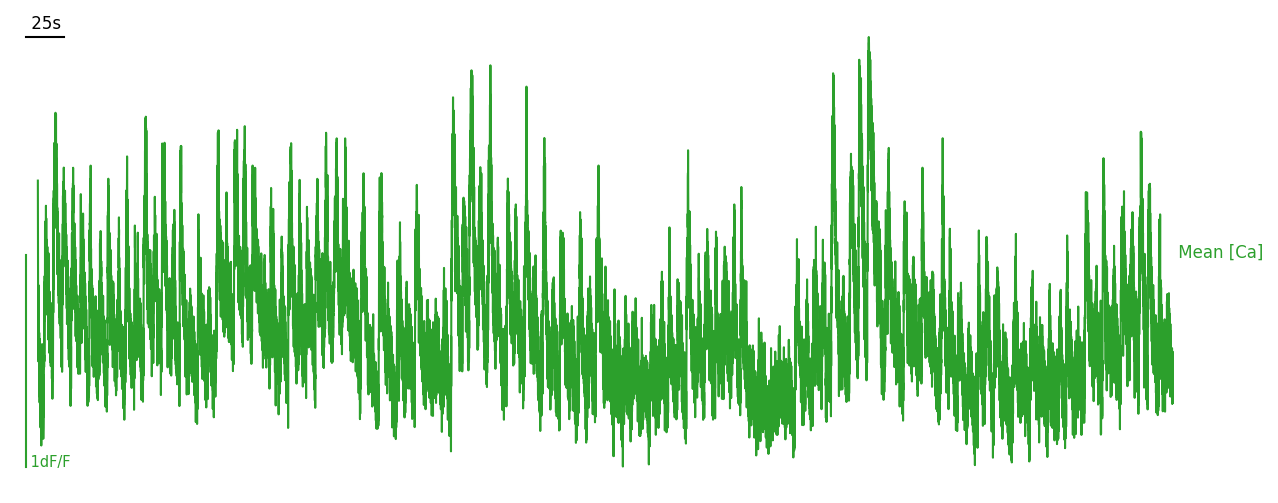

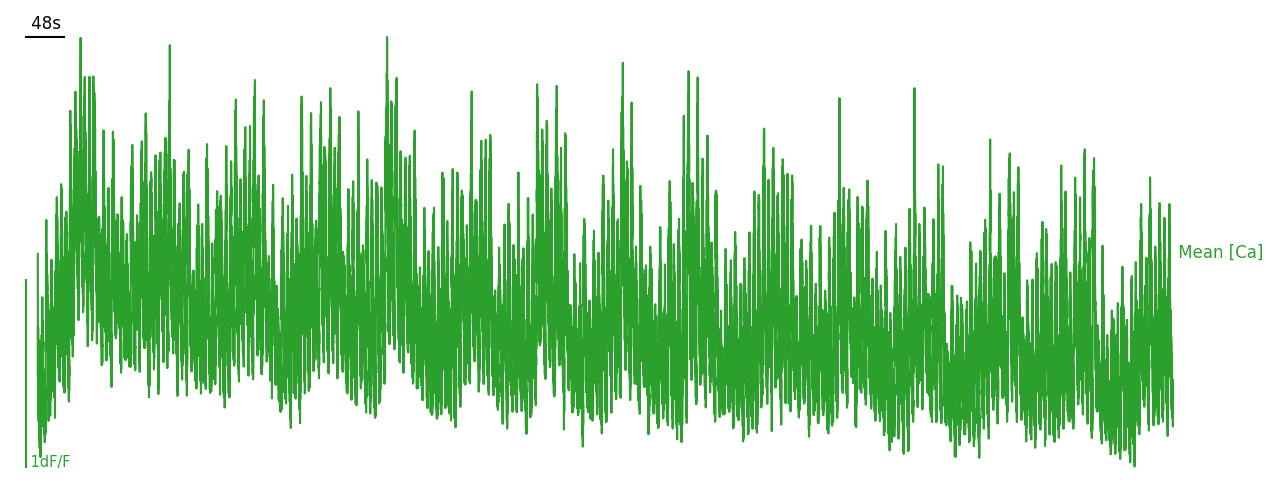

In [12]:
plot_data(DATA_8ori_keta, settings, '8ori')

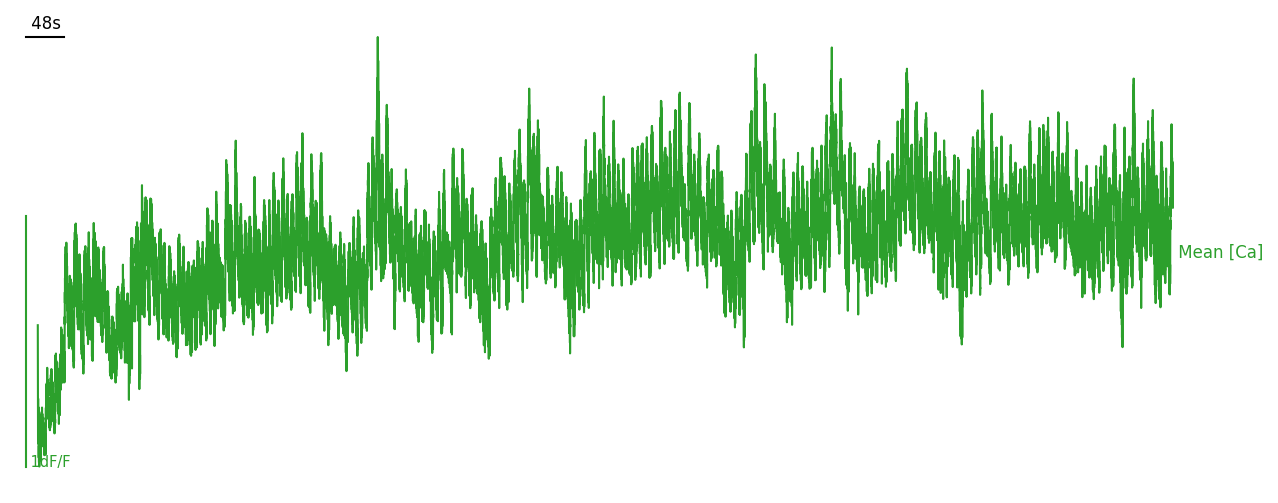

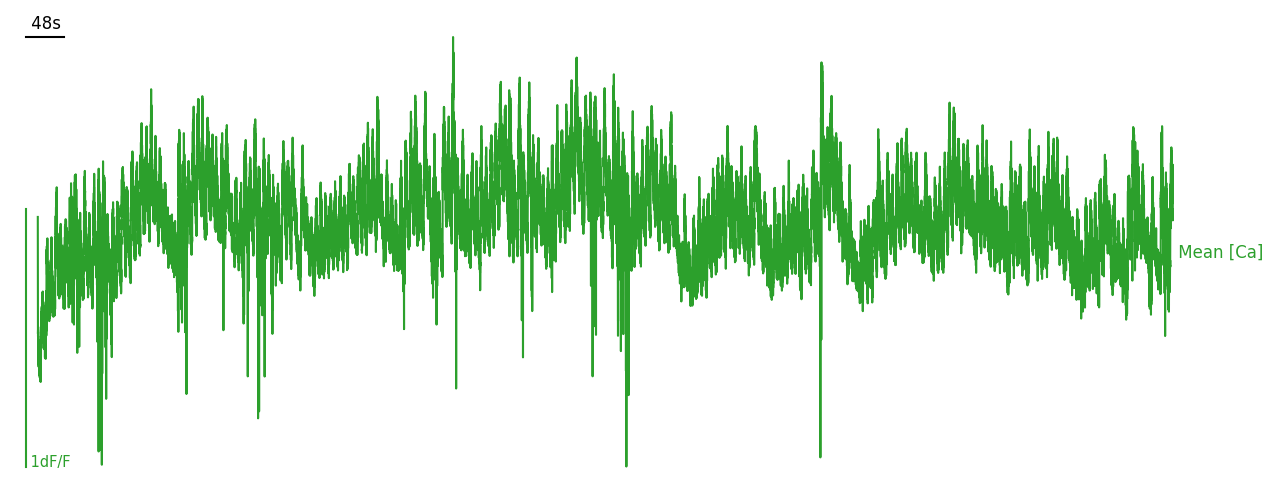

In [13]:
plot_data(DATA_8ori_saline, settings, '8ori')

## Other

In [5]:
def avg_group(data):
    avg_group = np.mean(data, axis=1)
    return avg_group

AttributeError: 'function' object has no attribute 'build_dFoF'

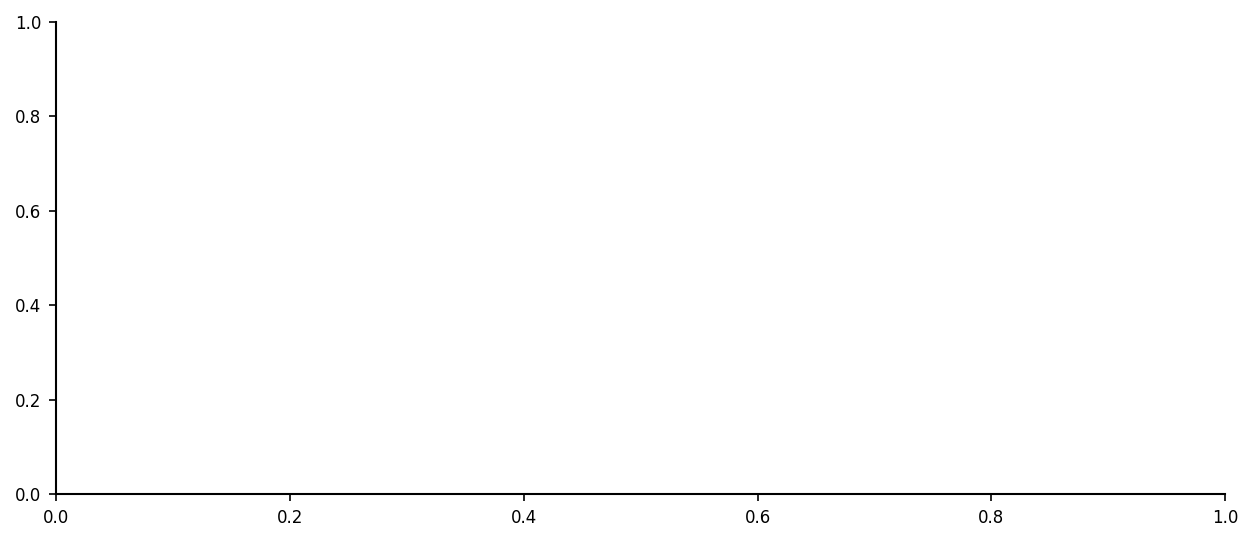

In [31]:
fig, AX = pt.figure(axes=(1,1), figsize=(3,5), wspace=0.15)
plot_raw(avg_group, tlim=[0, data.t_dFoF[-1]], settings=settings, ax=AX)
fig.savefig(os.path.join(os.path.expanduser('~'), 'Desktop', 'Injection monitoring', f'{data.filename}.png'))


In [8]:
for data in DATA_monitoring_keta:
    print(data.dFoF)
    avg_group(data.dFoF)

[[ 0.23579873  0.12420482  0.05965117 ...  1.6214094   1.3835773
   1.515454  ]
 [ 1.335251    1.3859171   0.914723   ...  0.42168197 -0.15301841
  -0.07295135]
 [ 0.8320836   0.83997124  0.48523986 ...  0.5274959   0.6847373
   0.6264178 ]
 ...
 [ 1.5750004   0.29645228  0.04667335 ...  0.3675563   1.1870468
   1.2446007 ]
 [ 2.031214    0.92280376  1.4273081  ...  0.8818547   0.58912766
   2.2280235 ]
 [ 1.7871479   1.9536219   0.9104858  ...  2.2071223   2.6765625
   2.728724  ]]
[[1.0301098  0.8956669  0.7043388  ... 0.8619833  0.8766249  0.8671098 ]
 [1.6936343  1.2054429  0.942869   ... 0.16881514 0.33485603 0.17881432]
 [1.1649797  0.8056597  0.5772104  ... 0.12565635 0.48283297 0.39542142]
 ...
 [1.5325146  0.9366194  1.4193428  ... 0.74658144 0.11913458 0.1804676 ]
 [1.455071   0.74886614 0.920944   ... 0.6522656  0.6769178  0.56278765]
 [1.0209686  3.0942192  3.9648244  ... 0.2849086  1.8762983  2.936612  ]]
[[ 1.5466051e-01  1.5684105e-01 -5.8045499e-03 ...  1.4726622e+01
  

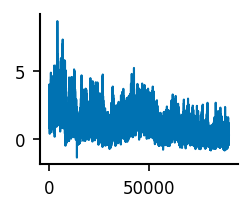

In [24]:
plt.plot(dFoF_all[3][21])

In [ ]:
DATA_monitoring_keta[3].dFoF
#4 elements because there are 4 files